# Homework 1: Finding Similar Documents

The task is to find similar document. 

By similar, we mean literally similar. For example, if a document A is consist of 80% document B's content and nothing else. The similarity between them is 80%. However, if the 2 document describes exactly the same topic but may use different sentences or words, their similarity will not be very high. For example, we choose our dataset from a novel "Yes, Prime Minister". Different chapters have same characters and similar stories but their document similarity does not exceed 10%. 

We apply the most naive Jaccard similarity in this assignment. The definition is $J(A,B)=\frac{|A\cap B|}{|A\cup B|}$

### Task 1: Shingle
The task is to constructs k–shingles of a given length $k$ (e.g., 10) from a given document, computes a hash value for each unique shingle and represents the document in the form of an ordered set of its hashed k-shingles.

In our implementation, we choose $k=10$. Shingles look like: "The Grand ", "ment Hosp","t Hospital". Shingle is simply cropping the document into 10 letters and do not preserve semantic information.

We do not use a hash function for each shingle. Instead, we maintain a global dictionary of shingles. We assign each unique shingle a unique number - a shingle ID. That's a so-called dictionary encoding

Every document has corresponding shingle instance, so that later we can get the document's shingle set.

In [129]:
from typing import Set, Dict
import os
import glob

# Global variables
# Size of each shingle 
K = 10 
# Shingle Dictionary
SHINGLE_DICT = {}
# next shingle_id
SID = 0 
class Shingling:
    def __init__(self, k=K, text=""):
        self.k = k
        self.shingle_set = set()
        if text:
            self._construct_hashed_shingles(text, SHINGLE_DICT)
    def _construct_hashed_shingles(self, text, shingle_dict):
        global SID
        # Data Preprocessing
        text = text.replace('\n', ' ').strip()
        # Construct Shingle list
        shingles = [text[i:i+self.k] for i in range(len(text) - self.k + 1)]
        for shingle in shingles:
            if shingle not in shingle_dict:
                shingle_dict[shingle] = SID
                SID += 1
            shingle_id = shingle_dict[shingle]
            self.shingle_set.add(shingle_id)
        return self.shingle_set
    def get_shingle_set(self):
        return self.shingle_set



### Task 2: Compare Set 
A class CompareSets computes the Jaccard similarity of two sets of integers – two sets of hashed shingles.

In [130]:
class CompareSets:
    # Compare Jaccard similarity between 2 set
    @staticmethod
    def compare(set1:Set[int],set2:Set[int]):
        if len(set1) == 0 and len(set2) == 0:
            return 1.0
        intersect = len(set1 & set2)
        union = len(set1 | set2)
        return intersect/union if union > 0 else 0.0

### Task 3: Min Hashing
The task is to implement a class $\texttt{MinHashing}$ that builds a minHash signature (a vector) of a given length n from a given set of integers (a set of hashed shingles).

Why do we need min-hashing? The motivation is that when there are large amount of shingles for each document, it is time-consuming to compare each pair of shingles. Instead, we randomly sample a small amount of shingle (for example 100 shingle from a total of 10^6), and compare the selected shingles. Minhashing is one way to randomly sample shingles from a large set. 

The similarity we obtained by the minhashing is of course not accurate. However, since our task is only to find similar document(by similar we mean 70%, 80% or higher similarity) and we do not care about whether the exact similarity is 17% or 31%. In this case, we later prove that the false negative rate for similar document is accepatable.

Let us consider a very simple case to understand the rational behind min-hashing sampling:

Suppose document A and document B has 80% similarity in original shingles, what is the probability of their similarity in terms of min-hashing shingles still larger than 80%? Or 70%? We draw 100 shingles out of 1000000 shingles and thus can consider each time we draw a shingle as a uniform process. 

The problem is to calculate binomial distribution and we have following relationship between the similarity threshold $k$ and the probability $P$ to achieve that threshold. The code is shown in the misc section. 

Overall, when the original document has 80% similarity, then almost 100% we ensure to preserve 70% similarity after minhashing, which is acceptable.

<img src="k_P_diagram.png" alt="" width="50%">


Now we look into the hash function. We randomly choose $a \in [1,c)$  and $b \in [0,c)$ and $c$ is a constant large prime number. The hash function $h_1(x) = (a_1 x + b_1) \mod c$. We sample 100 times to get 100 hash function, namely $a_1,...a_{100}$ and $b_1,...,b_{100}$.

The output of the minhashing process is that for each document, we have a $100*1$ vector (siganture). The $j^{th}$ value $x$ in the signature represents the row number (shingle id) $x$ such that $h_j(x)$ is the min value among all shingles in that document.

In [131]:
import random

class MinHashing:
    def __init__(self, L=100):
        # Generate Hash function
        self.hash_funcs = []
        self.prime = 2147483647  # Big Prime
        for _ in range(L):
            a = random.randint(1, self.prime - 1)
            b = random.randint(0, self.prime - 1)
            self.hash_funcs.append((a, b))
    
    def get_minhash_signature(self, shingle_set: Set[int]):
        signature = []
        for a, b in self.hash_funcs:
            min_hash = float('inf')
            for shingle_id in shingle_set:
                hash_value = (a * shingle_id + b) % self.prime
                if hash_value < min_hash:
                    min_hash = hash_value
            signature.append(min_hash if min_hash != float('inf') else 0)
        return signature

### Task 4: Compare Signature
The task is to implement A class CompareSignatures estimates the similarity of two integer vectors – minhash signatures – as a fraction of components in which they agree. The only difference between comparing sets and comparing signatures is that signature has order.

In [132]:
class CompareSignatures:
    # Compare MinHash signatures
    @staticmethod
    def compare(signature1, signature2):
        if len(signature1) != len(signature2):
            return 0.0
        if len(signature1) == 0:
            return 1.0
        matches = sum(1 for i in range(len(signature1)) if signature1[i] == signature2[i])
        return matches / len(signature1)

### Test
So far we have implemented 4 classes and finsihed all mandatory parts of the assignment.

In [133]:
# Load all documents from noveldataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def load_documents(dataset_path):
    """Load all txt files from the dataset directory"""
    documents = {}
    txt_files = glob.glob(os.path.join(dataset_path, "*.txt"))
    
    for file_path in txt_files:
        filename = os.path.basename(file_path)
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                content = f.read()
                documents[filename] = content
                print(f"Loaded {filename}: {len(content)} characters")
        except Exception as e:
            print(f"Error loading {filename}: {e}")
    
    return documents

# Load documents
dataset_path = "noveldataset"
documents = load_documents(dataset_path)
print(f"\nTotal documents loaded: {len(documents)}")
print("Document names:", list(documents.keys()))

Loaded xhtml_chapter002.txt: 60821 characters
Loaded xhtml_chapter002_modified.txt: 48735 characters
Loaded xhtml_chapter003.txt: 54967 characters
Loaded xhtml_chapter004.txt: 50599 characters
Loaded xhtml_chapter005.txt: 48928 characters
Loaded xhtml_chapter006.txt: 51898 characters
Loaded xhtml_chapter006_modiefied.txt: 50220 characters
Loaded xhtml_chapter007.txt: 44723 characters
Loaded xhtml_chapter008.txt: 44342 characters
Loaded xhtml_chapter008_modified.txt: 11476 characters

Total documents loaded: 10
Document names: ['xhtml_chapter002.txt', 'xhtml_chapter002_modified.txt', 'xhtml_chapter003.txt', 'xhtml_chapter004.txt', 'xhtml_chapter005.txt', 'xhtml_chapter006.txt', 'xhtml_chapter006_modiefied.txt', 'xhtml_chapter007.txt', 'xhtml_chapter008.txt', 'xhtml_chapter008_modified.txt']


In [134]:
# 计算所有文档对之间的相似度矩阵
def calculate_similarity_matrix(documents):
    doc_names = list(documents.keys())
    n_docs = len(doc_names)
    jaccard_matrix = np.zeros((n_docs, n_docs))
    minhash_matrix = np.zeros((n_docs, n_docs))
    
    minhasher = MinHashing(L=100)
    
    shingle_sets = {}
    signatures = {}
    
    print("Processing documents...")
    for i, (doc_name, content) in enumerate(documents.items()):
        shingling = Shingling(text=content)
        shingle_set = shingling.get_shingle_set()
        signature = minhasher.get_minhash_signature(shingle_set)
        
        shingle_sets[doc_name] = shingle_set
        signatures[doc_name] = signature
        print(f"Processed {doc_name}: {len(shingle_set)} shingles")
    
    print("\nCalculating similarity matrices...")
    for i, doc1 in enumerate(doc_names):
        for j, doc2 in enumerate(doc_names):
            jaccard_sim = CompareSets.compare(shingle_sets[doc1], shingle_sets[doc2])
            jaccard_matrix[i][j] = jaccard_sim
            minhash_sim = CompareSignatures.compare(signatures[doc1], signatures[doc2])
            minhash_matrix[i][j] = minhash_sim
    
    return jaccard_matrix, minhash_matrix, doc_names, signatures

jaccard_matrix, minhash_matrix, doc_names, signatures = calculate_similarity_matrix(documents)

Processing documents...
Processed xhtml_chapter002.txt: 51927 shingles
Processed xhtml_chapter002_modified.txt: 42088 shingles
Processed xhtml_chapter003.txt: 46975 shingles
Processed xhtml_chapter004.txt: 42763 shingles
Processed xhtml_chapter005.txt: 42086 shingles
Processed xhtml_chapter006.txt: 43522 shingles
Processed xhtml_chapter006_modiefied.txt: 42090 shingles
Processed xhtml_chapter007.txt: 39147 shingles
Processed xhtml_chapter008.txt: 38635 shingles
Processed xhtml_chapter008_modified.txt: 10619 shingles

Calculating similarity matrices...


## Optional Task: Locality Sensitive Hashing

What if there are not only a large amount of shingles (solved by minhashing) ? What if there are a lot of documents? for example 10^6 documents? Comparing similarity between each pair will be time consuming. 

This is exactly the motivation to introduce locality sensitive hashing. The main idea is that we already have a signature for each document, we further crop these  signatures into bands (e.g. every 5 items compose 1 band) and each band is then hashed to a certian integer value called (bucket). If 2 document collide on any band (all 5 items in that band are the same / has exact the same bucket), then they are considerd candidate pairs. We then examine all candiadte pairs by comparing their sigantures to kick out false positive pairs.

The tradeoff in the LSH is that we improve speeds at the cost of false negative rates, namely we may omit pairs that should have been classified as candidate pairs. However, we can tune the band size and similarity threshold to minimize false negative rate.

In [135]:
# LSH
class LSH:
    def __init__(self, b=20, r=5, t=0.8):
        self.b = b
        self.r = r
        self.t = t
        self.bands = [{} for _ in range(b)]  # List of bands and each is a dict of buckets
    def _hash_band(self, band):
        """hash a band into a bucket ID"""
        return hash(tuple(band))
    def index(self, doc_name, signature):
        """Given a signature matrix and document name, index it into LSH bands"""
        for i in range(self.b):
            start = i * self.r
            end = start + self.r
            band = signature[start:end]
            bucket_id = self._hash_band(band)
            if bucket_id not in self.bands[i]:
                self.bands[i][bucket_id] = set()
            self.bands[i][bucket_id].add(doc_name)
    def generate_candidates(self):
        """Generate candidate pairs from LSH bands"""
        candidates = set()
        for band in self.bands:
            for bucket_docs in band.values():
                if len(bucket_docs) > 1:
                    docs = list(bucket_docs)
                    for i in range(len(docs)):
                        for j in range(i + 1, len(docs)):
                            candidates.add((docs[i], docs[j]))
        return candidates
    def compare_candidate_signature(self, candidates, signatures):
        """Examine candidate pairs and return those above threshold t"""
        similar_pairs = []
        for doc1, doc2 in candidates:
            sig1 = signatures[doc1]
            sig2 = signatures[doc2]
            sim = CompareSignatures.compare(sig1, sig2)
            if sim >= self.t:
                similar_pairs.append((doc1, doc2, sim))
        return similar_pairs

In [136]:
# ...existing code...
def plot_similarity_matrix(doc_names, signatures, jaccard_matrix,minhash_matrix, lsh):
    """
    Plot three heatmaps side-by-side:
      1) Original Jaccard matrix (expects global jaccard_matrix)
      2) MinHash similarity matrix (expects global minhash_matrix)
      3) LSH candidate similarity matrix (values only for candidate pairs)
    This function uses the global variables jaccard_matrix and minhash_matrix
    produced earlier by calculate_similarity_matrix.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import os, re

    # short label extractor: try to find patterns like '002' or '002_mod'
    def short_label(name: str) -> str:
        base = os.path.splitext(name)[0]
        m = re.search(r'(\d{3}(?:_mod)?)', base)
        if m:
            return m.group(1)
        # fallback: keep short prefix (up to 8 chars) to avoid long labels
        return base if len(base) <= 8 else base[:8]

    n = len(doc_names)
    short_names = [short_label(nm) for nm in doc_names]
    name_to_idx = {name: i for i, name in enumerate(doc_names)}

    # Build LSH index and generate candidate pairs
    lsh.bands = [{} for _ in range(lsh.b)]
    for name in doc_names:
        lsh.index(name, signatures[name])
    candidates = lsh.generate_candidates()

    # Build LSH similarity matrix (only fill candidate pairs with their minhash similarity)
    lsh_matrix = np.zeros((n, n), dtype=float)
    for doc1, doc2 in candidates:
        i = name_to_idx[doc1]
        j = name_to_idx[doc2]
        sim = CompareSignatures.compare(signatures[doc1], signatures[doc2])
        lsh_matrix[i, j] = sim
        lsh_matrix[j, i] = sim

    # Ensure diagonals are 1
    np.fill_diagonal(lsh_matrix, 1.0)

    # Prepare plotting: use a blue-white-red colormap (coolwarm)
    fig, axes = plt.subplots(1, 3, figsize=(18, max(6, n * 0.25)))
    matrices = [
        (jaccard_matrix, "Original Jaccard"),
        (minhash_matrix, "MinHash Similarity"),
        (lsh_matrix, "LSH Candidate Similarity")
    ]

    for ax, (mat, title) in zip(axes, matrices):
        sns.heatmap(np.array(mat),
                    xticklabels=short_names,
                    yticklabels=short_names,
                    cmap="coolwarm",            # red-blue style
                    center=0.5,                # center color scale for similarity
                    vmin=0.0, vmax=1.0,
                    annot=(n <= 30), fmt=".2f",
                    cbar_kws={"shrink": 0.6},
                    ax=ax)
        ax.set_title(title)
        ax.set_xticklabels(short_names, rotation=45, ha="right")
        ax.set_yticklabels(short_names, rotation=0)

    plt.tight_layout()
    plt.show()

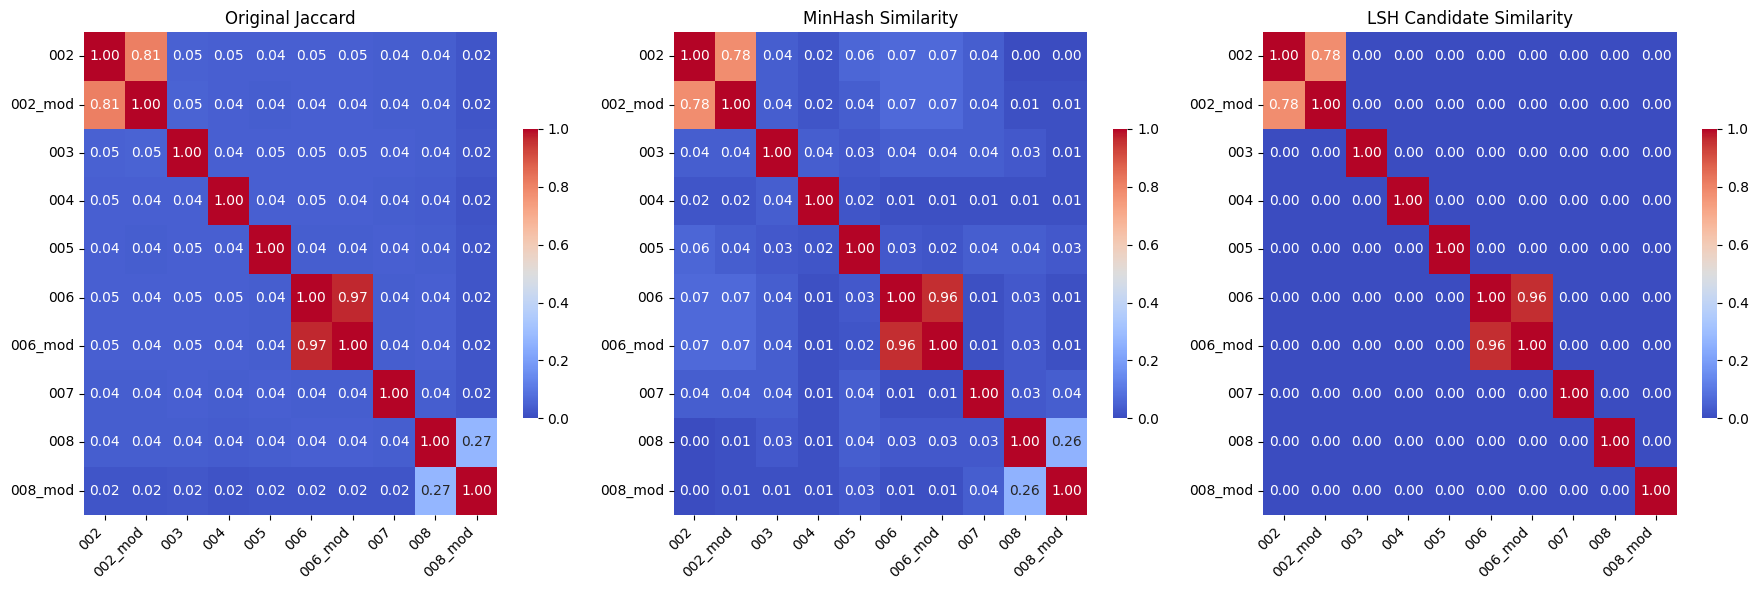

In [137]:
# Draw
lsh = LSH(b=20, r=5, t=0.8)
plot_similarity_matrix(doc_names, signatures, jaccard_matrix, minhash_matrix,lsh)

### Misc Code

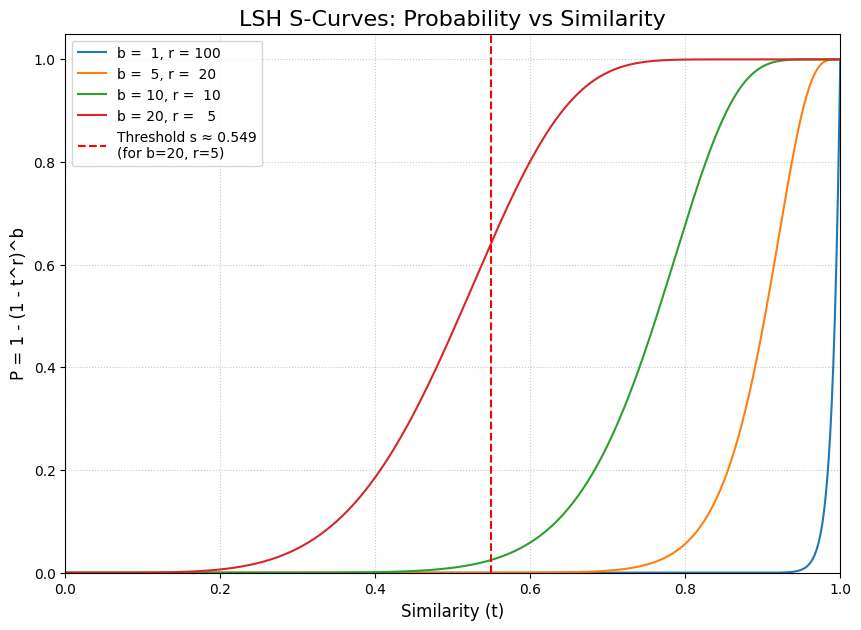

In [138]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_lsh_probability(t, r, b):
    """
    计算 LSH 公式 P = 1 - (1 - t^r)^b 的概率。
    此函数可用于 numpy 数组。
    """
    # np.power 会自动按元素计算
    return 1 - np.power(1 - np.power(t, r), b)

# --- 1. 准备数据 ---

# 创建一个 t (相似度) 的数组，从 0 到 1，包含 1000 个点以保证曲线平滑
t = np.linspace(0, 1, 1000)

# 定义要测试的 (b, r) 组合
combinations = [
    (1, 100),
    (5, 20),
    (10, 10),
    (20, 5)
]

# --- 2. 绘制图形 ---

plt.figure(figsize=(10, 7)) # 创建一个大小合适的画布

# 遍历所有组合并绘制
for b, r in combinations:
    # 计算 P (概率)
    P = calculate_lsh_probability(t, r, b)
    # 绘制 t 与 P 的关系图
    plt.plot(t, P, label=f'b = {b:2}, r = {r:3}')

# --- 3. 美化图形 ---

# 添加您在 slide 57 中看到的 (b=20, r=5) 对应的阈值 s
# 阈值 s ≈ (1/b)^(1/r)
threshold = (1/20)**(1/5)
plt.axvline(x=threshold, color='red', linestyle='--', 
            label=f'Threshold s ≈ {threshold:.3f}\n(for b=20, r=5)')

plt.title('LSH S-Curves: Probability vs Similarity', fontsize=16)
plt.xlabel('Similarity (t)', fontsize=12)
plt.ylabel('P = 1 - (1 - t^r)^b', fontsize=12)

# 设置 x 和 y 轴的范围
plt.xlim(0, 1)
plt.ylim(0, 1.05) # y 轴略微超出 1.0，以便查看

plt.grid(True, linestyle=':', alpha=0.7) # 添加辅助网格
plt.legend() # 显示图例

# 显示图形
plt.show()

In [139]:
import scipy.stats as stats

# n: 试验次数 (MinHash 签名的数量)
n = 100

# p: 单次成功的概率 (真实的 Jaccard 相似度)
p = 0.80

# k: 阈值 (我们关心的是 K > 80)
k_threshold = 75

# 计算 P(K > k_threshold)，其中 K 服从 B(n, p)
# stats.binom.sf(k, n, p) = P(K > k)
prob = stats.binom.sf(k_threshold, n, p)

print(f"试验次数 (n): {n}")
print(f"真实相似度 (p): {p}")
print(f"计算的概率 P(K > {k_threshold}): {prob}")
# 输出: 0.46016137006457336

试验次数 (n): 100
真实相似度 (p): 0.8
计算的概率 P(K > 75): 0.8686467826670116


图表已保存为 'k_P_diagram.png'


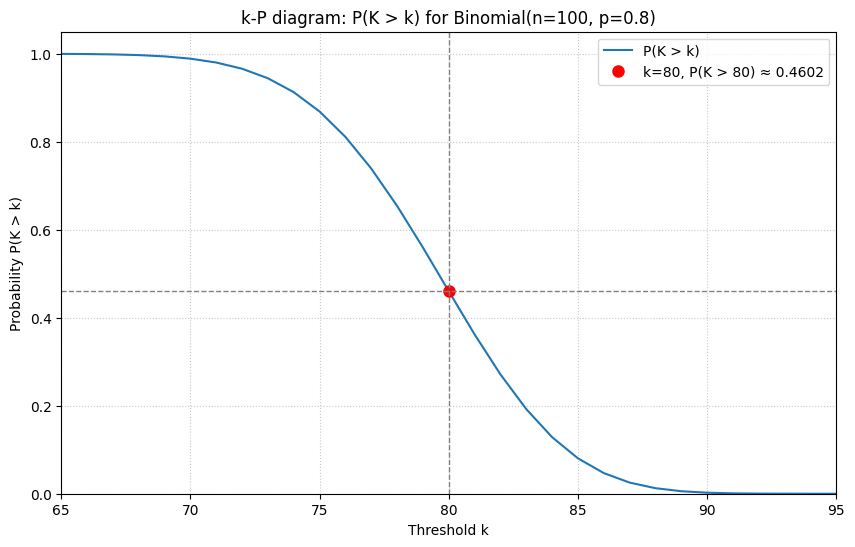

In [140]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# --- 1. 定义参数 ---
# n: MinHash 签名的数量 (试验总次数)
n = 100
# p: 真实的 Jaccard 相似度 (单次试验成功的概率)
p = 0.8

# --- 2. 生成绘图数据 ---
# k 代表 "匹配签名数" 的阈值
# 我们将 k 从 0 遍历到 100
k_values = np.arange(0, n + 1)

# 计算 P(K > k)，即生存函数 (Survival Function, sf)
# K ~ B(n, p)
# stats.binom.sf(k, n, p) = P(K > k)
probabilities = stats.binom.sf(k_values, n, p)

# --- 3. 绘制图表 ---
plt.figure(figsize=(10, 6))

# 绘制主曲线
plt.plot(k_values, probabilities, linestyle='-', marker='', label='P(K > k)')

# --- 4. 突出显示 k=80 的点 ---
k_highlight = 80
prob_highlight = stats.binom.sf(k_highlight, n, p)

# 标记该点
plt.plot(k_highlight, prob_highlight, 'ro', markersize=8, label=f'k={k_highlight}, P(K > {k_highlight}) ≈ {prob_highlight:.4f}')

# 添加辅助线
plt.axvline(x=k_highlight, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=prob_highlight, color='gray', linestyle='--', linewidth=1)

# --- 5. 设置图表样式 ---
plt.title(f'k-P diagram: P(K > k) for Binomial(n={n}, p={p})')
plt.xlabel('Threshold k')
plt.ylabel('Probability P(K > k)')

# 设置 x 轴范围以便更好地观察 k=80 附近的急剧变化
plt.xlim(65, 95)
plt.ylim(0, 1.05)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

# 保存图表
plt.savefig('k_P_diagram.png', dpi=600)

print(f"图表已保存为 'k_P_diagram.png'")